NAME:- Asha Bhokare

Roll no.:- 23102A0032


In [ ]:
install.packages("igraph")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(igraph)
library(ggplot2)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




In [ ]:
edges <- data.frame(
  from = c("A", "A", "A", "B", "B", "C", "C", "D", "D", "E",
           "E", "F", "F", "G", "H"),
  to   = c("B", "C", "D", "C", "E", "D", "F", "E", "F", "F",
           "G", "G", "H", "H", "A")
)

print(edges)

   from to
1     A  B
2     A  C
3     A  D
4     B  C
5     B  E
6     C  D
7     C  F
8     D  E
9     D  F
10    E  F
11    E  G
12    F  G
13    F  H
14    G  H
15    H  A


In [ ]:
network <- graph_from_data_frame(
  edges,
  directed = FALSE
)

print(network)

IGRAPH 411aef1 UN-- 8 15 -- 
+ attr: name (v/c)
+ edges from 411aef1 (vertex names):
 [1] A--B A--C A--D B--C B--E C--D C--F D--E D--F E--F E--G F--G F--H G--H A--H


In [ ]:
V(network)$name
E(network)

[1] "A" "B" "C" "D" "E" "F" "G" "H"

+ 15/15 edges from 411aef1 (vertex names):
 [1] A--B A--C A--D B--C B--E C--D C--F D--E D--F E--F E--G F--G F--H G--H A--H

In [ ]:
cat("Number of Nodes:", vcount(network), "\n")
cat("Number of Edges:", ecount(network), "\n")
cat("Network Density:", edge_density(network), "\n")

Number of Nodes: 8 
Number of Edges: 15 
Network Density: 0.5357143 


In [ ]:
degree_values <- degree(network)

degree_table <- data.frame(
  Node = names(degree_values),
  Degree = as.numeric(degree_values)
)

print(degree_table)

  Node Degree
1    A      4
2    B      3
3    C      4
4    D      4
5    E      4
6    F      5
7    G      3
8    H      3


In [ ]:
most_connected <- names(which.max(degree_values))

cat(
  "Most connected node:",
  most_connected,
  "\nDegree:",
  max(degree_values)
)

Most connected node: F 
Degree: 5

In [ ]:
betweenness_values <- betweenness(network)

betweenness_table <- data.frame(
  Node = names(betweenness_values),
  Betweenness = round(as.numeric(betweenness_values), 2)
)

print(betweenness_table)

  Node Betweenness
1    A        2.33
2    B        0.83
3    C        1.17
4    D        1.17
5    E        2.33
6    F        3.33
7    G        0.50
8    H        1.33


In [ ]:
closeness_values <- closeness(network)

closeness_table <- data.frame(
  Node = names(closeness_values),
  Closeness = round(as.numeric(closeness_values), 3)
)

print(closeness_table)

  Node Closeness
1    A     0.100
2    B     0.091
3    C     0.100
4    D     0.100
5    E     0.100
6    F     0.111
7    G     0.091
8    H     0.091


In [ ]:
pagerank_values <- page_rank(network)$vector

pagerank_table <- data.frame(
  Node = names(pagerank_values),
  PageRank = round(as.numeric(pagerank_values), 3)
)

print(pagerank_table)

  Node PageRank
1    A    0.133
2    B    0.103
3    C    0.131
4    D    0.131
5    E    0.133
6    F    0.161
7    G    0.104
8    H    0.104


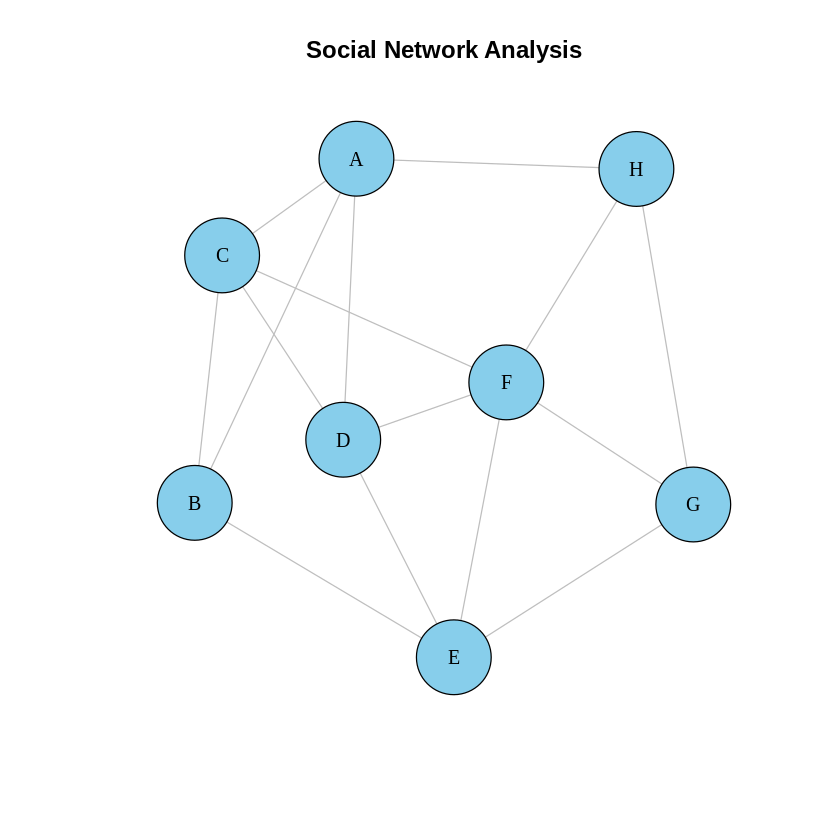

In [ ]:
set.seed(123)

plot(
  network,
  vertex.color = "skyblue",
  vertex.size = 30,
  vertex.label.color = "black",
  vertex.label.cex = 1,
  edge.color = "gray",
  main = "Social Network Analysis"
)

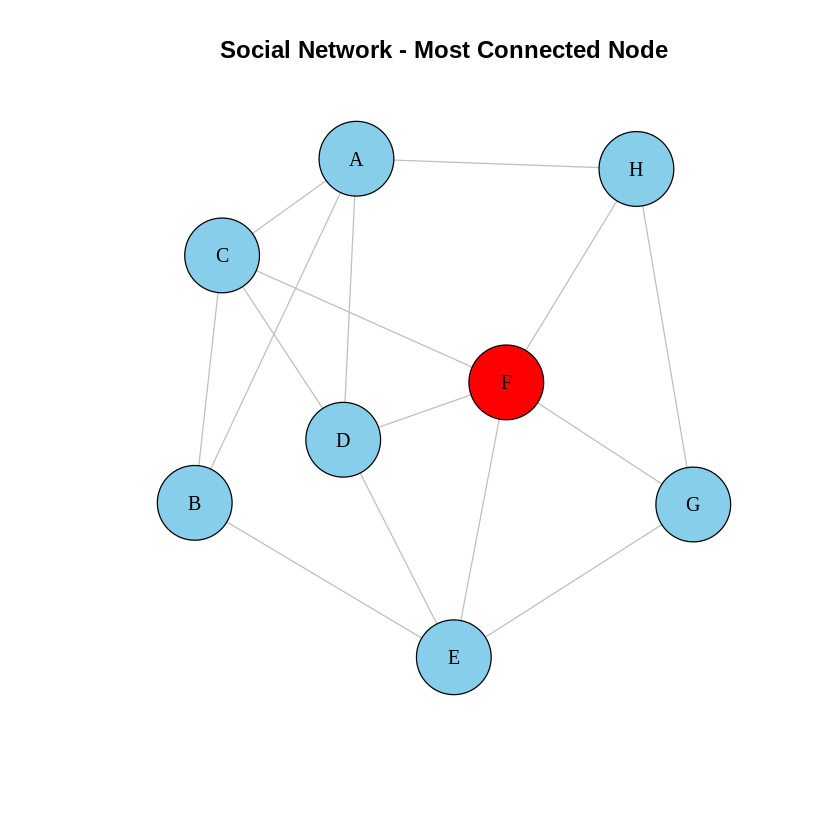

In [ ]:
set.seed(123)

node_colors <- rep("skyblue", vcount(network))

node_colors[which(V(network)$name == most_connected)] <- "red"

plot(
  network,
  vertex.color = node_colors,
  vertex.size = 30,
  vertex.label.color = "black",
  edge.color = "gray",
  main = "Social Network - Most Connected Node"
)

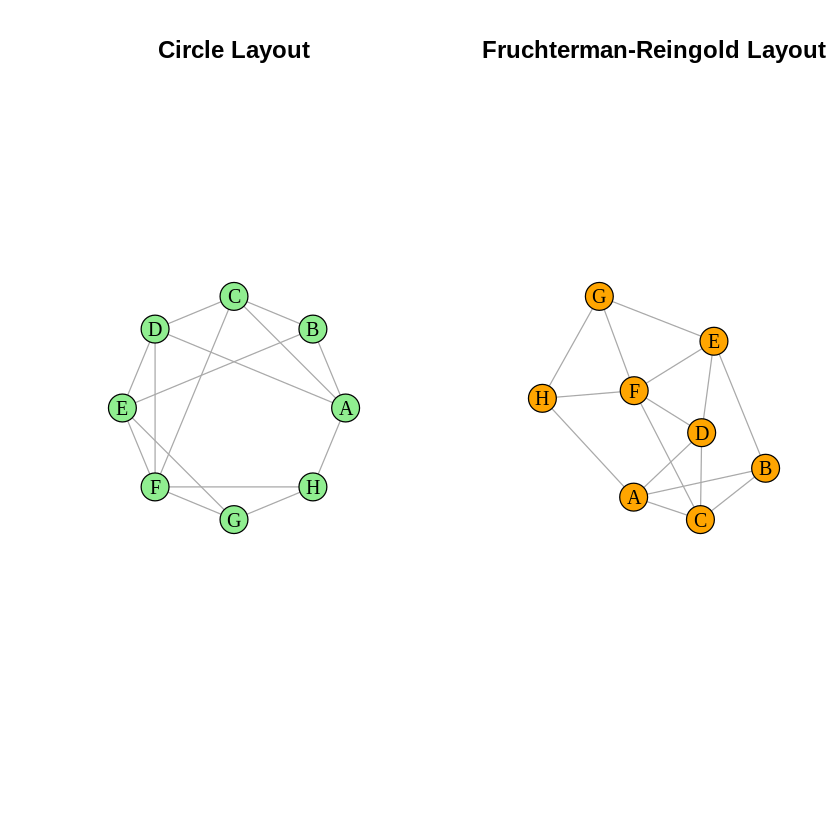

In [ ]:
set.seed(123)

par(mfrow = c(1, 2))

# Circle layout
plot(
  network,
  layout = igraph::layout_in_circle(network),
  vertex.color = "lightgreen",
  vertex.size = 25,
  vertex.label.color = "black",
  main = "Circle Layout"
)

# Fruchterman-Reingold layout
plot(
  network,
  layout = igraph::layout_with_fr(network),
  vertex.color = "orange",
  vertex.size = 25,
  vertex.label.color = "black",
  main = "Fruchterman-Reingold Layout"
)

par(mfrow = c(1, 1))

In [ ]:
cat("===== SOCIAL NETWORK ANALYSIS =====\n")
cat("Number of Nodes:", vcount(network), "\n")
cat("Number of Edges:", ecount(network), "\n")
cat("Network Density:", round(edge_density(network), 3), "\n")
cat("Most Connected Node:", most_connected, "\n")
cat("Maximum Degree:", max(degree_values), "\n")

===== SOCIAL NETWORK ANALYSIS =====
Number of Nodes: 8 
Number of Edges: 15 
Network Density: 0.536 
Most Connected Node: F 
Maximum Degree: 5 
